In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('aldimi_inventario_real.csv', parse_dates=['fecha'])
df.shape

(500, 25)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fecha                     500 non-null    datetime64[ns]
 1   item_id                   500 non-null    int64         
 2   tipo_item                 500 non-null    object        
 3   nombre_item               500 non-null    object        
 4   stock_actual              500 non-null    int64         
 5   stock_minimo              500 non-null    int64         
 6   stock_maximo              500 non-null    int64         
 7   consumo_promedio_dia      500 non-null    int64         
 8   lead_time_dias            500 non-null    int64         
 9   costo_unitario            500 non-null    float64       
 10  costo_consumo_diario      500 non-null    float64       
 11  cobertura_dias            500 non-null    float64       
 12  dias_stock_restante   

In [10]:
df.head(10)

,fecha,item_id,tipo_item,nombre_item,stock_actual,stock_minimo,stock_maximo,consumo_promedio_dia,lead_time_dias,costo_unitario,...,alerta_stock_14d,proveedor_id,nombre_proveedor,lead_time_proveedor_dias,costo_por_item_proveedor,ocupacion_pacientes_mes,mes,año,dia_semana,es_fin_de_semana
0,2024-10-01,105,Consumable,Ventilator,1542,264,1018,108,17,4467.55,...,0,V001,MedSupplies Inc.,5,0.5,500,10,2024,Tuesday,0
1,2024-10-02,100,Equipment,Ventilator,2487,656,3556,55,12,5832.29,...,0,V001,MedSupplies Inc.,5,0.5,500,10,2024,Wednesday,0
2,2024-10-03,103,Equipment,Surgical Mask,2371,384,5562,470,6,16062.98,...,1,V001,MedSupplies Inc.,5,0.5,500,10,2024,Thursday,0
3,2024-10-04,103,Consumable,Surgical Mask,2038,438,1131,207,15,744.10,...,1,V002,EquipMed Co.,30,20000.0,500,10,2024,Friday,0
4,2024-10-05,107,Equipment,IV Drip,2410,338,1013,158,12,15426.53,...,0,V003,HealthTools Ltd.,15,5000.0,500,10,2024,Saturday,1
5,2024-10-06,109,Equipment,IV Drip,2258,402,1715,386,26,15246.06,...,1,V002,EquipMed Co.,30,20000.0,500,10,2024,Sunday,1
6,2024-10-07,103,Consumable,IV Drip,387,210,3765,207,24,1631.28,...,1,V003,HealthTools Ltd.,15,5000.0,500,10,2024,Monday,0
7,2024-10-08,105,Equipment,IV Drip,123,502,2161,257,11,16620.81,...,1,V002,EquipMed Co.,30,20000.0,500,10,2024,Tuesday,0
8,2024-10-09,102,Consumable,Ventilator,790,751,1801,16,20,3441.26,...,0,V001,MedSupplies Inc.,5,0.5,500,10,2024,Wednesday,0
9,2024-10-10,104,Equipment,Gloves,2448,28,1314,418,5,2729.08,...,1,V002,EquipMed Co.,30,20000.0,500,10,2024,Thursday,0


In [11]:
print(f'Período: {df["fecha"].min().date()} a {df["fecha"].max().date()}')
print(f'Ítems únicos: {df["nombre_item"].unique()}')
print(f'Proveedores:')
df[['proveedor_id', 'nombre_proveedor', 'lead_time_proveedor_dias']].drop_duplicates()

Período: 2024-10-01 a 2026-02-12
Ítems únicos: ['Ventilator' 'Surgical Mask' 'IV Drip' 'Gloves' 'X-ray Machine']
Proveedores:


,proveedor_id,nombre_proveedor,lead_time_proveedor_dias
0,V001,MedSupplies Inc.,5
3,V002,EquipMed Co.,30
4,V003,HealthTools Ltd.,15


In [12]:
df.isnull().sum()

,0
fecha,0
item_id,0
tipo_item,0
nombre_item,0
stock_actual,0
stock_minimo,0
stock_maximo,0
consumo_promedio_dia,0
lead_time_dias,0
costo_unitario,0


In [13]:
print('Duplicados:', df.duplicated().sum())
print('Stock negativo:', (df['stock_actual'] < 0).sum())
print('Consumo <= 0:', (df['consumo_promedio_dia'] <= 0).sum())
print('stock_min > stock_max:', (df['stock_minimo'] > df['stock_maximo']).sum())

Duplicados: 0
Stock negativo: 0
Consumo <= 0: 0
stock_min > stock_max: 13


In [14]:
cols = ['stock_actual', 'stock_minimo', 'stock_maximo', 'consumo_promedio_dia',
        'lead_time_dias', 'dias_stock_restante', 'costo_unitario']
df[cols].describe().round(2)

,stock_actual,stock_minimo,stock_maximo,consumo_promedio_dia,lead_time_dias,dias_stock_restante,costo_unitario
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,2458.64,485.98,3288.83,261.80,15.12,23.94,10277.33
std,1390.08,292.05,1602.65,143.98,8.61,58.04,5728.68
min,69.00,10.00,500.00,2.00,1.00,0.20,4.23
25%,1307.75,215.75,1847.75,150.50,7.00,5.48,5422.46
50%,2411.50,496.50,3311.00,257.00,16.00,9.30,10129.96
75%,3719.00,734.25,4696.00,392.00,23.00,17.70,15206.31
max,4976.00,995.00,5992.00,499.00,29.00,598.00,19984.16


In [15]:
df.groupby('nombre_item')[cols].mean().round(1)

,stock_actual,stock_minimo,stock_maximo,consumo_promedio_dia,lead_time_dias,dias_stock_restante,costo_unitario
nombre_item,,,,,,,
Gloves,2487.9,484.8,3236.8,267.4,16.0,19.6,9513.2
IV Drip,2563.4,499.3,3341.8,252.6,16.5,24.9,10248.1
Surgical Mask,2346.8,464.5,3449.8,269.0,14.6,21.9,10322.7
Ventilator,2388.9,518.9,2972.6,244.9,13.8,25.1,10497.4
X-ray Machine,2492.7,461.5,3431.3,275.7,14.5,28.2,10820.9


In [16]:
print(df['alerta_stock_7d'].value_counts(normalize=True).round(3))
print(df['alerta_stock_14d'].value_counts(normalize=True).round(3))

alerta_stock_7d
0    0.644
1    0.356
Name: proportion, dtype: float64
alerta_stock_14d
1    0.676
0    0.324
Name: proportion, dtype: float64


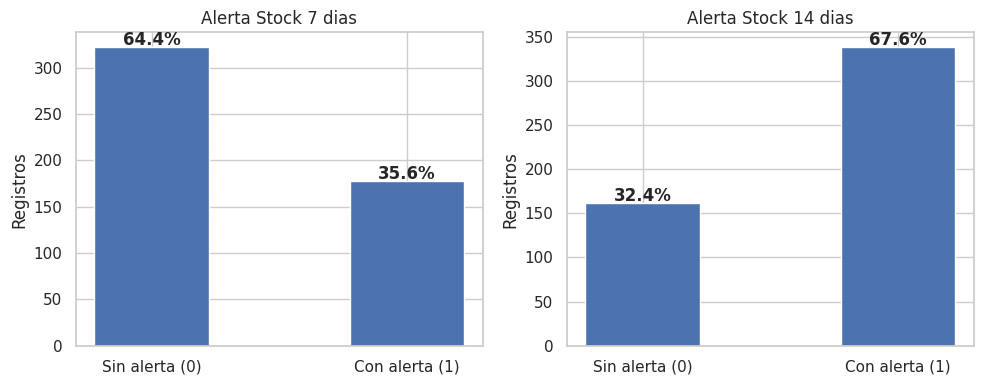

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, titulo in zip(axes,
        ['alerta_stock_7d', 'alerta_stock_14d'],
        ['Alerta Stock 7 dias', 'Alerta Stock 14 dias']):
    conteo = df[col].value_counts().sort_index()
    pct = df[col].value_counts(normalize=True).sort_index() * 100
    bars = ax.bar(['Sin alerta (0)', 'Con alerta (1)'], conteo.values, width=0.45)
    for bar, p in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 2, f'{p:.1f}%', ha='center', fontweight='bold')
    ax.set_title(titulo)
    ax.set_ylabel('Registros')

plt.tight_layout()
plt.show()

In [18]:
df[cols].skew().round(2)

,0
stock_actual,0.04
stock_minimo,0.03
stock_maximo,-0.04
consumo_promedio_dia,-0.10
lead_time_dias,-0.04
dias_stock_restante,6.14
costo_unitario,0.01


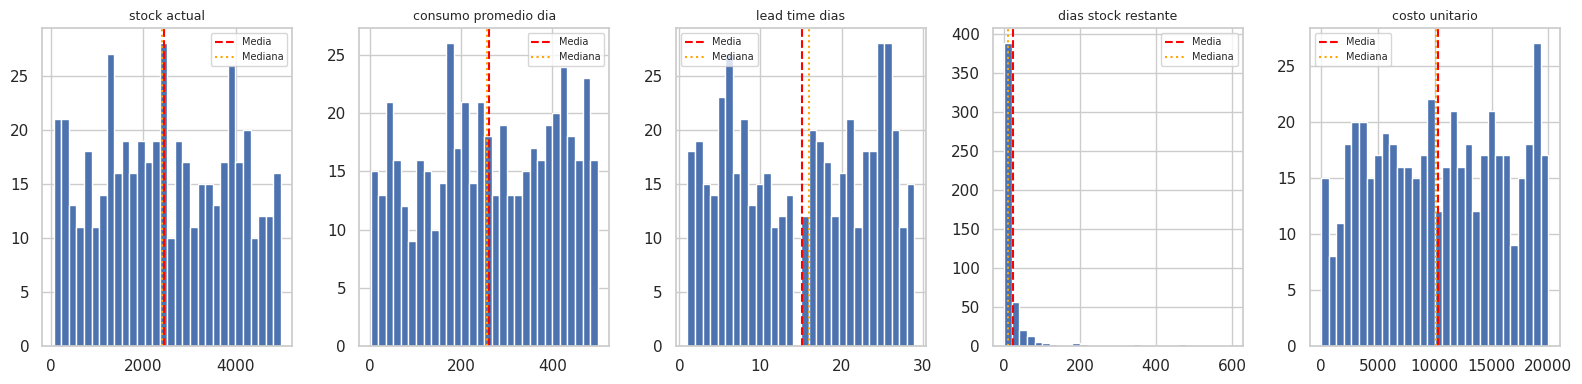

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

vars_plot = ['stock_actual', 'consumo_promedio_dia', 'lead_time_dias',
             'dias_stock_restante', 'costo_unitario']

for ax, col in zip(axes, vars_plot):
    ax.hist(df[col], bins=30, edgecolor='white')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label='Media')
    ax.axvline(df[col].median(), color='orange', linestyle=':', linewidth=1.5, label='Mediana')
    ax.set_title(col.replace('_', ' '), fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 7. Boxplots por ítem

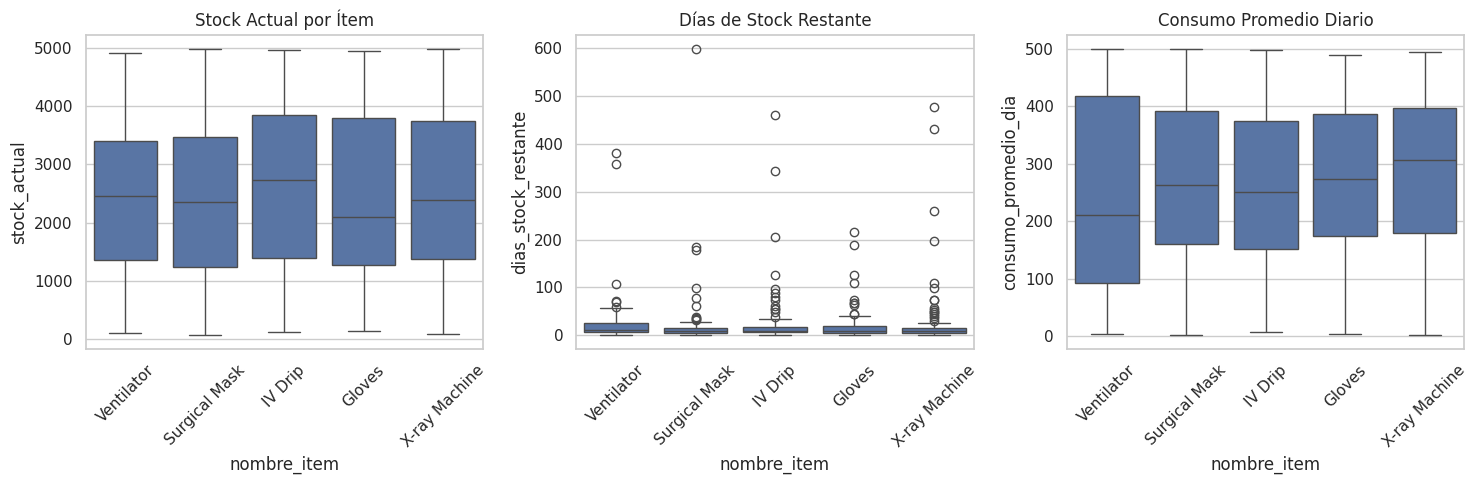

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x='nombre_item', y='stock_actual', ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Stock Actual por Ítem')

sns.boxplot(data=df, x='nombre_item', y='dias_stock_restante', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Días de Stock Restante')

sns.boxplot(data=df, x='nombre_item', y='consumo_promedio_dia', ax=axes[2])
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_title('Consumo Promedio Diario')

plt.tight_layout()
plt.show()

## Detección de outliers (IQR)


In [22]:
resultados = []
for col in vars_plot:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    resultados.append({'variable': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                       'lim_inf': Q1 - 1.5 * IQR, 'lim_sup': Q3 + 1.5 * IQR,
                       'n_outliers': n_out})

pd.DataFrame(resultados).round(1)

,variable,Q1,Q3,IQR,lim_inf,lim_sup,n_outliers
0,stock_actual,1307.8,3719.0,2411.2,-2309.1,7335.9,0
1,consumo_promedio_dia,150.5,392.0,241.5,-211.8,754.2,0
2,lead_time_dias,7.0,23.0,16.0,-17.0,47.0,0
3,dias_stock_restante,5.5,17.7,12.2,-12.9,36.0,60
4,costo_unitario,5422.5,15206.3,9783.9,-9253.3,29882.1,0


##  Evolución temporal del stock por ítem

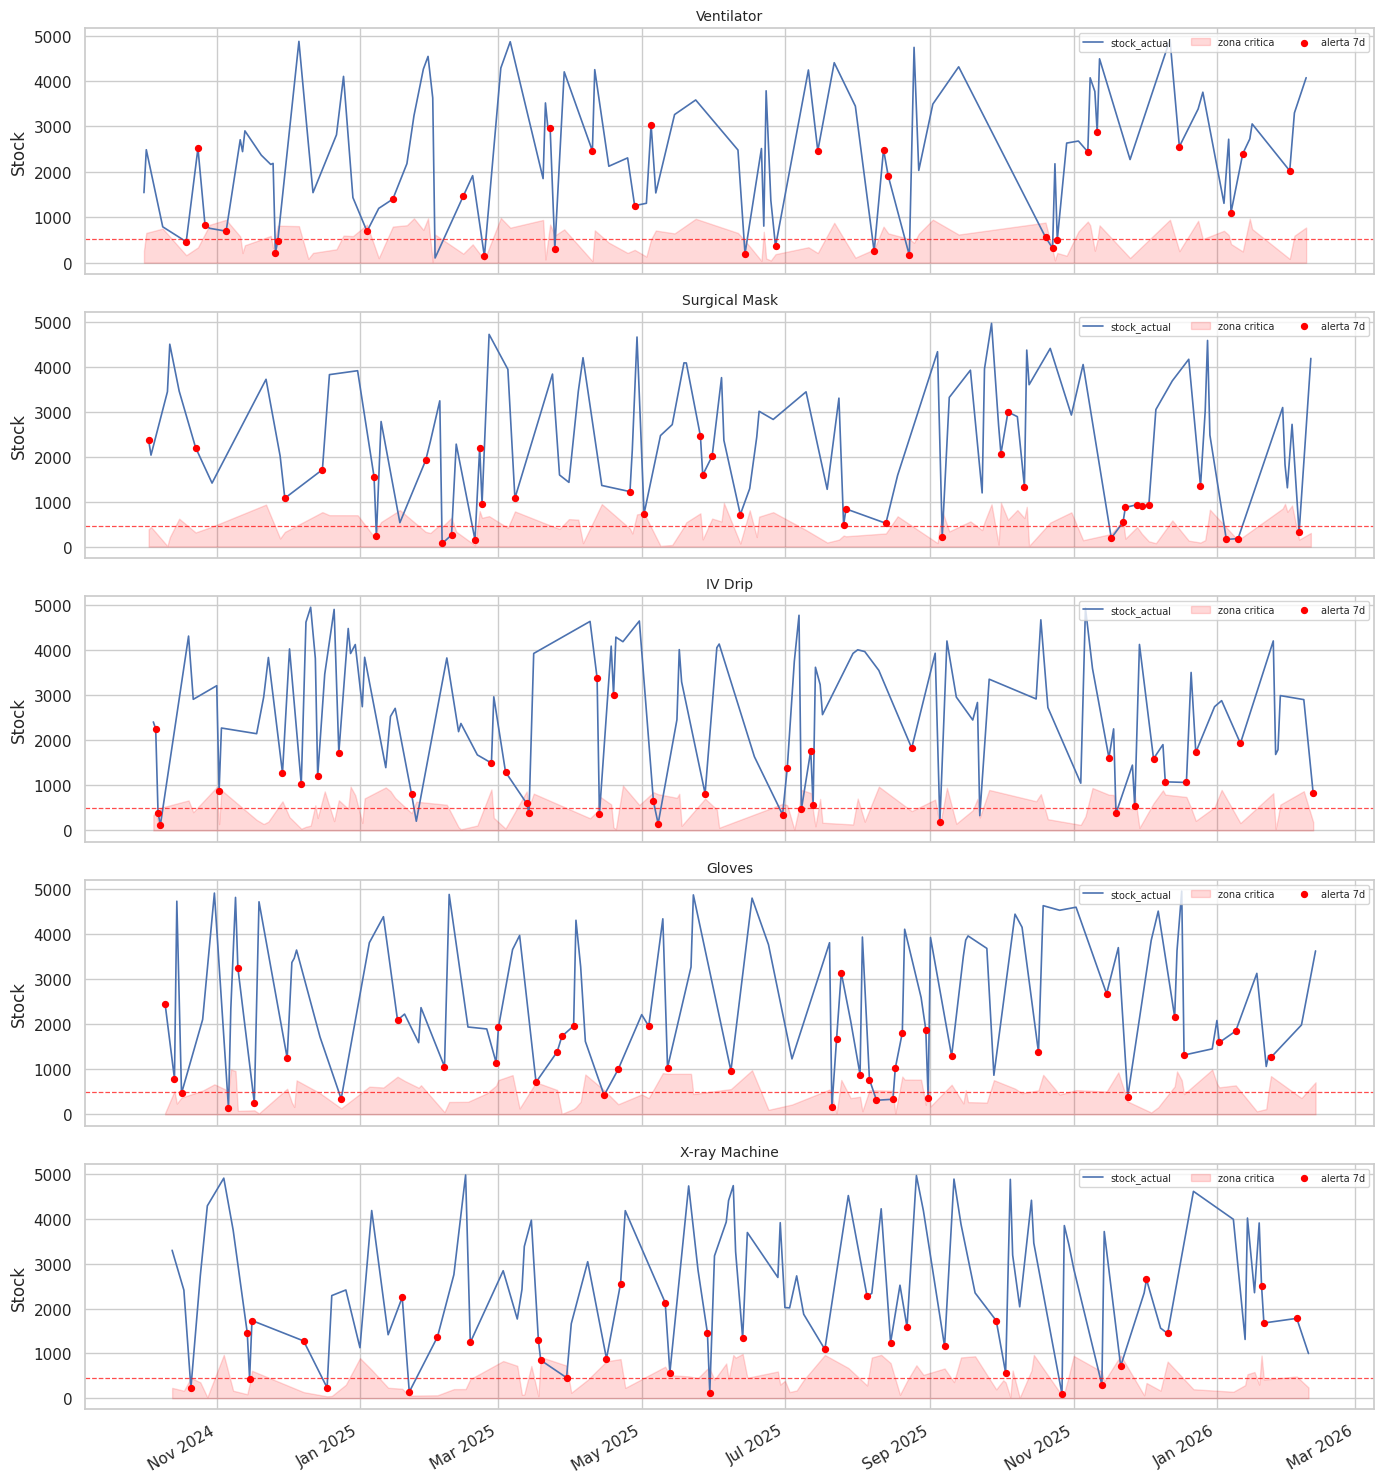

In [23]:
fig, axes = plt.subplots(5, 1, figsize=(14, 15), sharex=True)

for ax, item in zip(axes, items):
    sub = df[df['nombre_item'] == item].sort_values('fecha')
    ax.plot(sub['fecha'], sub['stock_actual'], linewidth=1.2, label='stock_actual')
    ax.fill_between(sub['fecha'], 0, sub['stock_minimo'], alpha=0.15, color='red', label='zona critica')
    ax.axhline(sub['stock_minimo'].mean(), color='red', linestyle='--', linewidth=0.9, alpha=0.7)
    alertas = sub[sub['alerta_stock_7d'] == 1]
    ax.scatter(alertas['fecha'], alertas['stock_actual'], color='red', s=18, zorder=5, label='alerta 7d')
    ax.set_title(item, fontsize=10)
    ax.set_ylabel('Stock')
    ax.legend(fontsize=7, loc='upper right', ncol=3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Análisis de correlaciones


In [24]:
cols_corr = ['stock_actual', 'stock_minimo', 'consumo_promedio_dia', 'lead_time_dias',
             'dias_stock_restante', 'stock_bajo_minimo', 'costo_unitario',
             'alerta_stock_7d', 'alerta_stock_14d']

df[cols_corr].corr()[['alerta_stock_7d', 'alerta_stock_14d']].drop(
    ['alerta_stock_7d', 'alerta_stock_14d']).round(3)

,alerta_stock_7d,alerta_stock_14d
stock_actual,-0.668,-0.367
stock_minimo,-0.040,-0.013
consumo_promedio_dia,0.414,0.698
lead_time_dias,0.007,-0.059
dias_stock_restante,-0.261,-0.433
stock_bajo_minimo,0.353,0.182
costo_unitario,-0.017,0.007


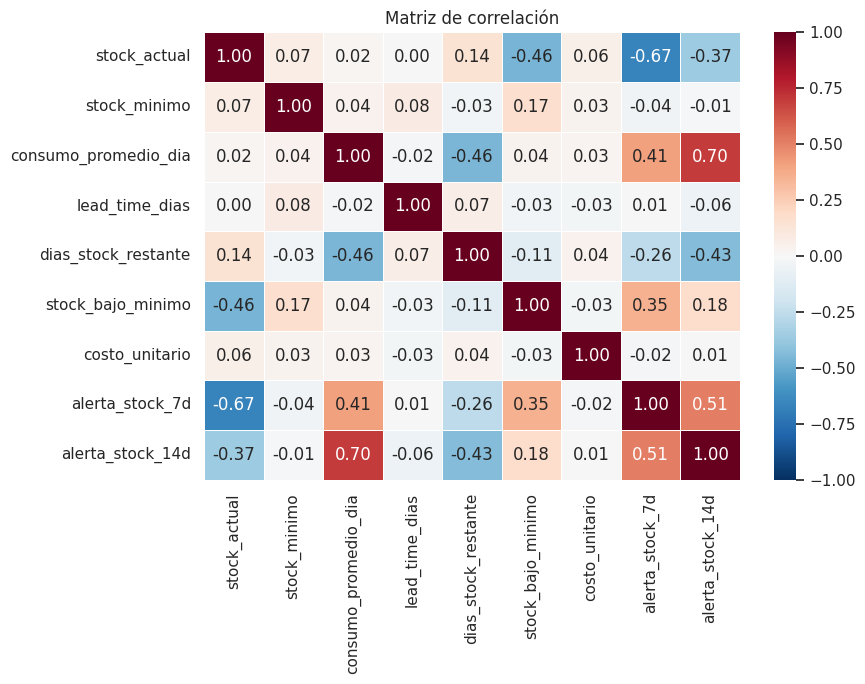

In [25]:
fig, ax = plt.subplots(figsize=(9, 7))

corr_matrix = df[cols_corr].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.show()

## Análisis de proveedores


In [26]:
df.groupby('nombre_proveedor').agg(
    lead_time=('lead_time_proveedor_dias', 'first'),
    alerta_7d_pct=('alerta_stock_7d', 'mean'),
    alerta_14d_pct=('alerta_stock_14d', 'mean'),
    n=('fecha', 'count')
).round(3)

,lead_time,alerta_7d_pct,alerta_14d_pct,n
nombre_proveedor,,,,
EquipMed Co.,30,0.417,0.744,156
HealthTools Ltd.,15,0.340,0.712,156
MedSupplies Inc.,5,0.319,0.590,188


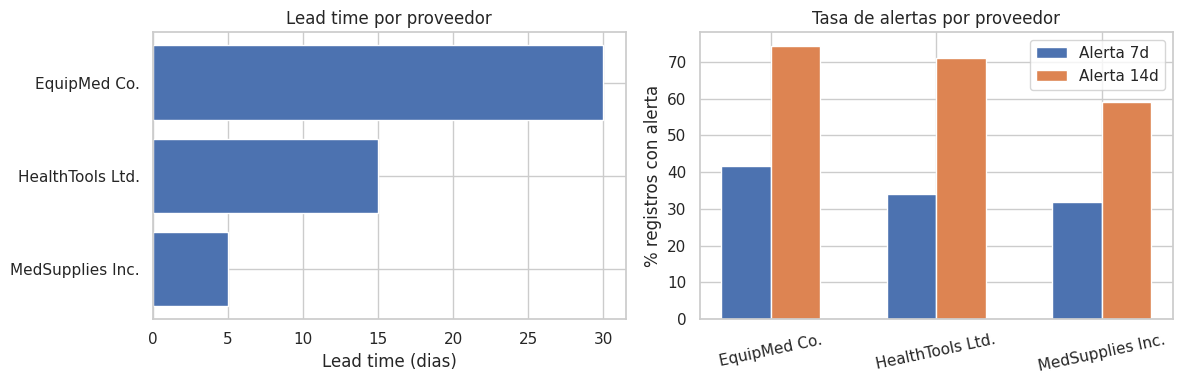

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

prov_lt = df.groupby('nombre_proveedor')['lead_time_proveedor_dias'].first().sort_values()
axes[0].barh(prov_lt.index, prov_lt.values)
axes[0].set_xlabel('Lead time (dias)')
axes[0].set_title('Lead time por proveedor')

alerta_prov = df.groupby('nombre_proveedor').agg(
    t7=('alerta_stock_7d', 'mean'), t14=('alerta_stock_14d', 'mean')
) * 100

x = range(len(alerta_prov))
w = 0.3
axes[1].bar([i - w/2 for i in x], alerta_prov['t7'], width=w, label='Alerta 7d')
axes[1].bar([i + w/2 for i in x], alerta_prov['t14'], width=w, label='Alerta 14d')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(alerta_prov.index, rotation=12)
axes[1].set_ylabel('% registros con alerta')
axes[1].set_title('Tasa de alertas por proveedor')
axes[1].legend()

plt.tight_layout()
plt.show()

##  Separabilidad de clases


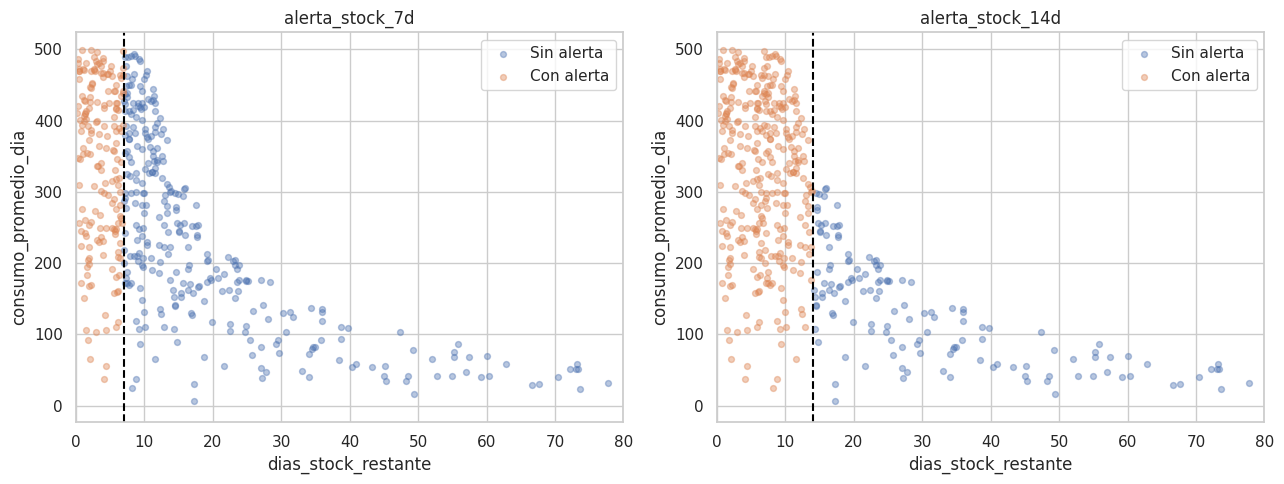

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, ['alerta_stock_7d', 'alerta_stock_14d']):
    for val, label in [(0, 'Sin alerta'), (1, 'Con alerta')]:
        sub = df[df[col] == val]
        ax.scatter(sub['dias_stock_restante'], sub['consumo_promedio_dia'],
                   alpha=0.4, s=18, label=label)
    umbral = 7 if '7d' in col else 14
    ax.axvline(umbral, color='black', linestyle='--', linewidth=1.5)
    ax.set_xlim(0, 80)
    ax.set_xlabel('dias_stock_restante')
    ax.set_ylabel('consumo_promedio_dia')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()